# 🔍 DefectVision — 03. Entraînement YOLOv8

**Objectif** : Entraîner YOLOv8 pour détecter les défauts industriels sur MVTec AD (bottle).

**Workflow** :
```
dataset.yaml (Drive) → YOLOv8n → Entraînement T4 → Évaluation → HuggingFace Hub
```

## 0. Setup

In [1]:
# Vérifier le GPU
!nvidia-smi

Tue Mar 10 19:16:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.8 MB/s eta 0:00:00


In [3]:
# Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os

DRIVE_BASE  = Path('/content/drive/MyDrive/defect-vision')
YOLO_PATH   = DRIVE_BASE / 'data' / 'yolo' / 'bottle'
YAML_PATH   = YOLO_PATH / 'dataset.yaml'
MODELS_PATH = DRIVE_BASE / 'models'
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print(f'✅ dataset.yaml : {YAML_PATH}')
print(f'✅ Models path  : {MODELS_PATH}')
assert YAML_PATH.exists(), '❌ dataset.yaml introuvable — lance le notebook 02 dabord'

Mounted at /content/drive
✅ dataset.yaml : /content/drive/MyDrive/defect-vision/data/yolo/bottle/dataset.yaml
✅ Models path  : /content/drive/MyDrive/defect-vision/models


In [4]:
# Vérifier le contenu du dataset.yaml
with open(YAML_PATH) as f:
    print(f.read())

names:
- defect
nc: 1
path: /content/drive/MyDrive/defect-vision/data/yolo/bottle
test: test/images
train: train/images
val: val/images



## 1. Configuration de l'entraînement

In [5]:
# Hyperparamètres
CONFIG = {
    'model'     : 'yolov8n.pt',   # nano — rapide sur T4
    'epochs'    : 50,
    'imgsz'     : 640,
    'batch'     : 16,
    'patience'  : 10,             # early stopping
    'lr0'       : 0.01,
    'project'   : '/content/runs',
    'name'      : 'yolov8_bottle',
    'device'    : 0,              # GPU
    'workers'   : 2,
    'exist_ok'  : True,
    'pretrained': True,
    'augment'   : True,
    'cache'     : False,
}

print('✅ Configuration :')
for k, v in CONFIG.items():
    print(f'  {k:12s} : {v}')

✅ Configuration :
  model        : yolov8n.pt
  epochs       : 50
  imgsz        : 640
  batch        : 16
  patience     : 10
  lr0          : 0.01
  project      : /content/runs
  name         : yolov8_bottle
  device       : 0
  workers      : 2
  exist_ok     : True
  pretrained   : True
  augment      : True
  cache        : False


## 2. Entraînement

In [6]:
from ultralytics import YOLO
import time

# Charger le modèle YOLOv8 nano pré-entraîné
model = YOLO(CONFIG['model'])
print(f'✅ Modèle chargé : {CONFIG["model"]}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Modèle chargé : yolov8n.pt


In [7]:
# Lancer l'entraînement
print('🚀 Démarrage de l entraînement...')
start = time.time()

results = model.train(
    data     = str(YAML_PATH),
    epochs   = CONFIG['epochs'],
    imgsz    = CONFIG['imgsz'],
    batch    = CONFIG['batch'],
    patience = CONFIG['patience'],
    lr0      = CONFIG['lr0'],
    project  = CONFIG['project'],
    name     = CONFIG['name'],
    device   = CONFIG['device'],
    workers  = CONFIG['workers'],
    exist_ok = CONFIG['exist_ok'],
    pretrained = CONFIG['pretrained'],
    augment  = CONFIG['augment'],
    cache    = CONFIG['cache'],
)

elapsed = time.time() - start
print(f'\n✅ Entraînement terminé en {elapsed/60:.1f} minutes')

🚀 Démarrage de l entraînement...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/defect-vision/data/yolo/bottle/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_bottle, nbs=64, nms=False, opset=None, opt

## 3. Résultats et métriques

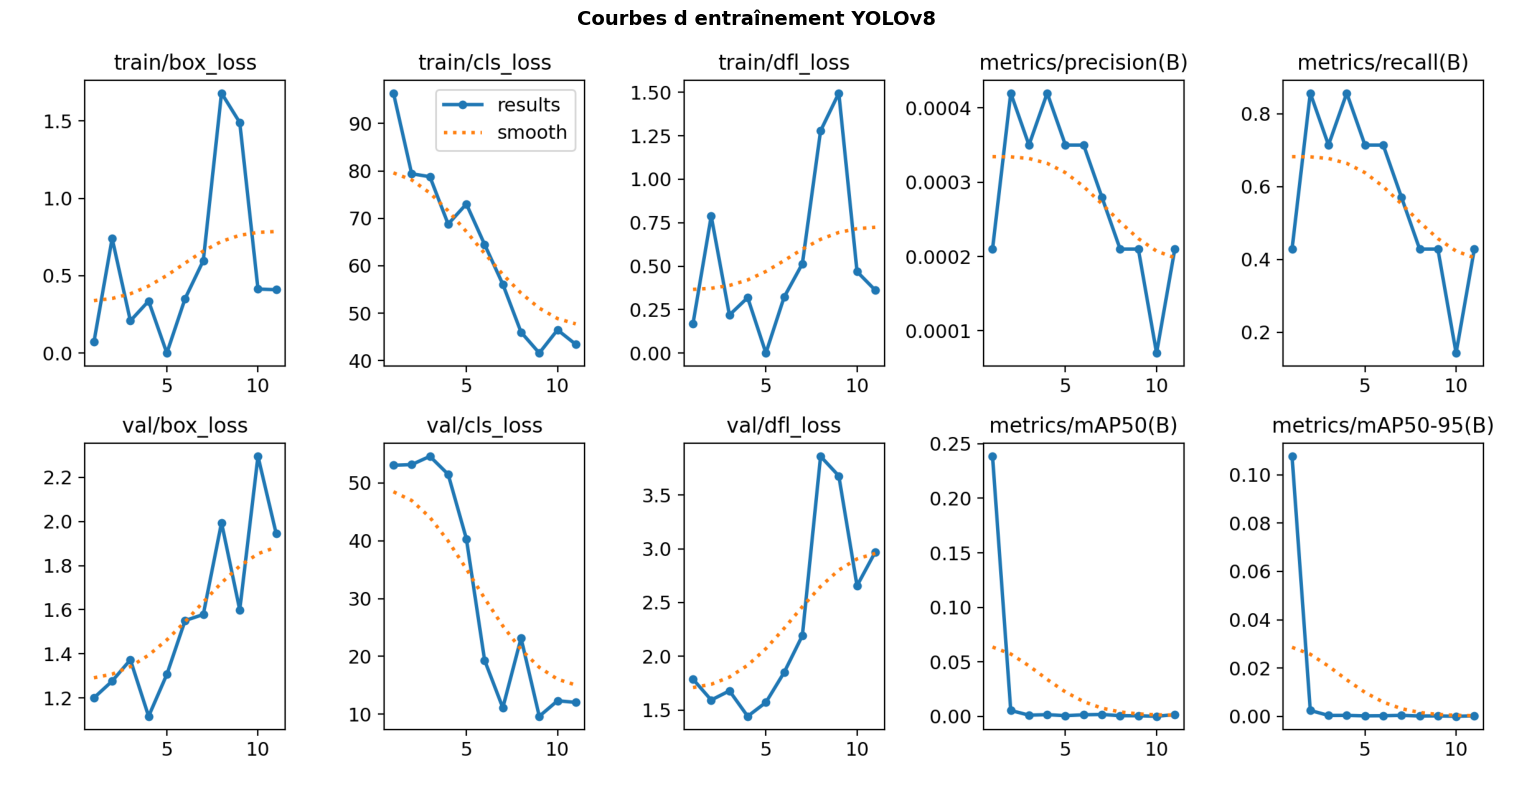

✅ Courbes sauvegardées


In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

RUN_PATH = Path(CONFIG['project']) / CONFIG['name']

# Afficher les courbes d'entraînement
results_png = RUN_PATH / 'results.png'
if results_png.exists():
    img = mpimg.imread(str(results_png))
    plt.figure(figsize=(18, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Courbes d entraînement YOLOv8', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Courbes sauvegardées')

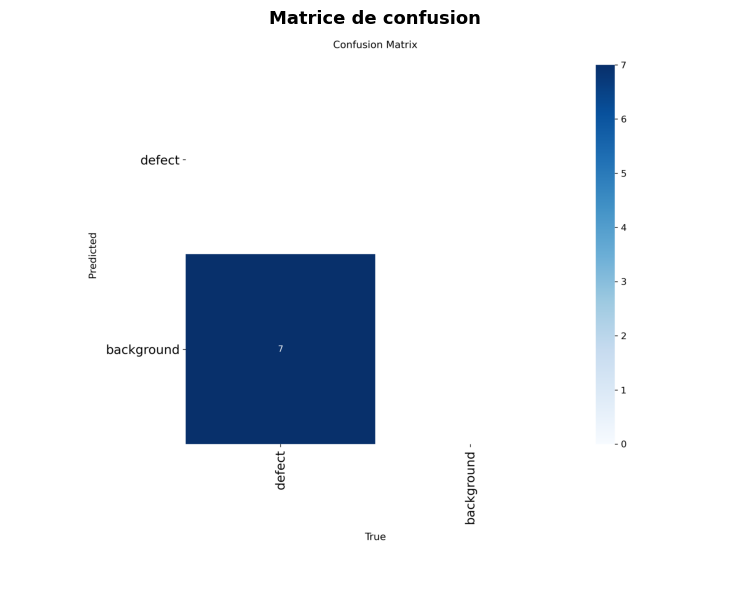

In [9]:
# Afficher la matrice de confusion
confusion_png = RUN_PATH / 'confusion_matrix.png'
if confusion_png.exists():
    img = mpimg.imread(str(confusion_png))
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Matrice de confusion', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [10]:
# Évaluation sur le test set
print('📊 Évaluation sur le test set...')
metrics = model.val(
    data   = str(YAML_PATH),
    split  = 'test',
    device = 0,
)

print('\n=== Métriques Test Set ===')
print(f'  mAP50      : {metrics.box.map50:.4f}')
print(f'  mAP50-95   : {metrics.box.map:.4f}')
print(f'  Precision  : {metrics.box.mp:.4f}')
print(f'  Recall     : {metrics.box.mr:.4f}')

📊 Évaluation sur le test set...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 1.4±0.2 MB/s, size: 523.7 KB)
val: Scanning /content/drive/MyDrive/defect-vision/data/yolo/bottle/test/labels... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 1.6it/s 12.4s
val: New cache created: /content/drive/MyDrive/defect-vision/data/yolo/bottle/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0it/s 2.0s
                   all         20         21    0.00283       0.81     0.0933     0.0305
Speed: 11.3ms preprocess, 20.8ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /content/runs/detect/val

=== Métriques Test Set ===
  mAP50      : 0.0933
  mAP50-95   : 0.0305
  Precision  : 0.0028
  Recall     : 0.8095


## 4. Inférence — visualisation des prédictions

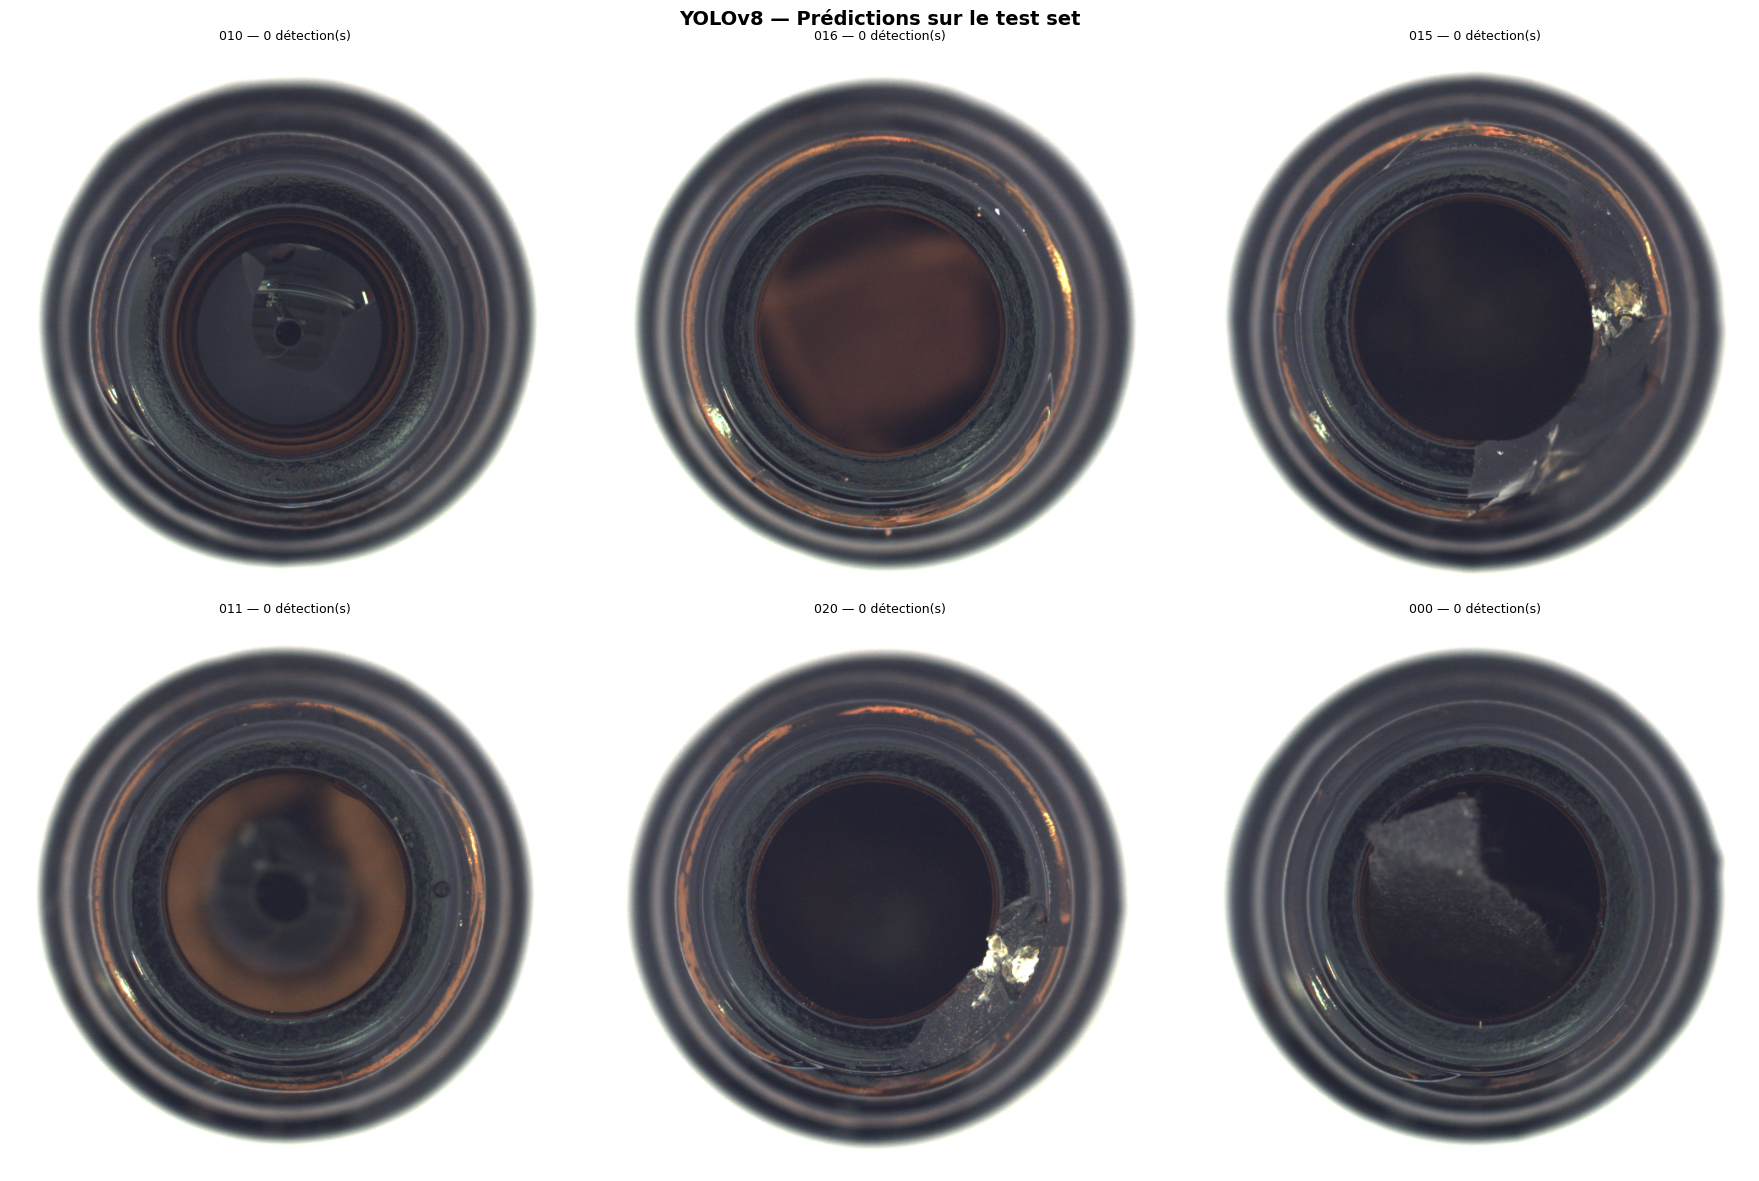

✅ Prédictions visualisées


In [11]:
import cv2
import numpy as np
import random

# Charger le meilleur modèle
best_model = YOLO(str(RUN_PATH / 'weights' / 'best.pt'))

# Prendre 6 images du test set
test_imgs = list((YOLO_PATH / 'test' / 'images').glob('*.png'))
samples   = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('YOLOv8 — Prédictions sur le test set', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, img_path in enumerate(samples):
    # Inférence
    preds = best_model.predict(str(img_path), conf=0.25, verbose=False)
    result_img = preds[0].plot()  # image avec bboxes dessinées
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    n_det = len(preds[0].boxes)
    axes[i].imshow(result_img)
    axes[i].set_title(f'{img_path.stem} — {n_det} détection(s)', fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('yolov8_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prédictions visualisées')

## 5. Sauvegarde sur Drive

In [12]:
import shutil

# Sauvegarder best.pt et last.pt sur Drive
dest = MODELS_PATH / 'yolov8_bottle'
dest.mkdir(parents=True, exist_ok=True)

shutil.copy2(RUN_PATH / 'weights' / 'best.pt', dest / 'best.pt')
shutil.copy2(RUN_PATH / 'weights' / 'last.pt', dest / 'last.pt')

# Sauvegarder aussi les courbes
for png in ['results.png', 'confusion_matrix.png']:
    src = RUN_PATH / png
    if src.exists():
        shutil.copy2(src, dest / png)

print(f'✅ Modèle sauvegardé sur Drive : {dest}')
print(f'  best.pt : {(dest / "best.pt").stat().st_size / 1e6:.1f} MB')

✅ Modèle sauvegardé sur Drive : /content/drive/MyDrive/defect-vision/models/yolov8_bottle
  best.pt : 6.2 MB


## 6. Push sur HuggingFace Hub

In [ ]:
from huggingface_hub import HfApi, login

# ⚠️ Remplace par ton token HuggingFace
# Génère-le sur : https://huggingface.co/settings/tokens
HF_TOKEN    = 'TON_TOKEN_HUGGINGFACE'
HF_USERNAME = 'Chasston'
REPO_NAME   = 'defect-vision-yolov8-bottle'

login(token=HF_TOKEN)
api = HfApi()

# Créer le repo si besoin
repo_id = f'{HF_USERNAME}/{REPO_NAME}'
api.create_repo(repo_id=repo_id, repo_type='model', exist_ok=True)
print(f'✅ Repo HuggingFace : {repo_id}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Repo HuggingFace : Chasston/defect-vision-yolov8-bottle


In [14]:
# Créer un README pour HuggingFace
readme_content = f"""---
tags:
- object-detection
- computer-vision
- yolov8
- defect-detection
- industrial
datasets:
- mvtec-ad
---

# DefectVision — YOLOv8 Defect Detection (bottle)

YOLOv8n fine-tuned on MVTec AD dataset for industrial defect detection.

## Category : bottle
- **Defect types** : broken_large, broken_small, contamination
- **Classes** : 1 (defect)
- **Image size** : 640x640

## Metrics (test set)
- mAP50     : {metrics.box.map50:.4f}
- mAP50-95  : {metrics.box.map:.4f}
- Precision : {metrics.box.mp:.4f}
- Recall    : {metrics.box.mr:.4f}

## Usage
```python
from ultralytics import YOLO
from huggingface_hub import hf_hub_download

path  = hf_hub_download(repo_id='{repo_id}', filename='best.pt')
model = YOLO(path)
results = model.predict('your_image.png', conf=0.25)
```

## Author
[{HF_USERNAME}](https://huggingface.co/{HF_USERNAME})
"""

with open('/content/README.md', 'w') as f:
    f.write(readme_content)

print('✅ README généré')

✅ README généré


In [15]:
# Uploader les fichiers sur HuggingFace
files_to_upload = [
    (dest / 'best.pt',             'best.pt'),
    (dest / 'results.png',         'results.png'),
    ('/content/README.md',         'README.md'),
]

for local_path, hf_filename in files_to_upload:
    if Path(local_path).exists():
        api.upload_file(
            path_or_fileobj = str(local_path),
            path_in_repo    = hf_filename,
            repo_id         = repo_id,
            repo_type       = 'model',
        )
        print(f'  ✅ Uploadé : {hf_filename}')

print(f'\n🎉 Modèle disponible sur : https://huggingface.co/{repo_id}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...els/yolov8_bottle/best.pt:   9%|8         |  535kB / 6.24MB            

  ✅ Uploadé : best.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...yolov8_bottle/results.png: 100%|##########|  282kB /  282kB            

  ...yolov8_bottle/results.png: 100%|##########|  282kB /  282kB            

  ✅ Uploadé : results.png
  ✅ Uploadé : README.md

🎉 Modèle disponible sur : https://huggingface.co/Chasston/defect-vision-yolov8-bottle


## ✅ Résumé

| Info | Valeur |
|------|--------|
| Modèle | YOLOv8n fine-tuned |
| Dataset | MVTec AD — bottle |
| Drive | `/defect-vision/models/yolov8_bottle/` |
| HuggingFace | `Chasston/defect-vision-yolov8-bottle` |
| Prochain notebook | `04_patchcore.ipynb` |

**Prochaine étape** : Entraîner PatchCore (détection d'anomalies non supervisée).